In [1]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [3]:
IMG_SIZE = 96

def preprocess(image, label):
    image = tf.expand_dims(image, -1)              # (28,28) -> (28,28,1)
    image = tf.image.grayscale_to_rgb(image)         # (28,28,1) -> (28,28,3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)
    return image, label

In [4]:
BATCH_SIZE = 32

# x_train, y_train, x_test, y_test are the original (unreshaped) Fashion MNIST arrays
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [5]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(train_ds, validation_data=test_ds, epochs=20,
                     callbacks=[reduce_lr, early_stop])

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 21ms/step - accuracy: 0.8043 - loss: 0.5645 - val_accuracy: 0.8737 - val_loss: 0.3614 - learning_rate: 1.0000e-04
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 17ms/step - accuracy: 0.8724 - loss: 0.3551 - val_accuracy: 0.8876 - val_loss: 0.3206 - learning_rate: 1.0000e-04
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - accuracy: 0.8878 - loss: 0.3118 - val_accuracy: 0.8896 - val_loss: 0.3030 - learning_rate: 1.0000e-04
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - accuracy: 0.8960 - loss: 0.2876 - val_accuracy: 0.8958 - val_loss: 0.2905 - learning_rate: 1.0000e-04
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.9035 - loss: 0.2658 - val_accuracy: 0.8993 - val_loss: 0.2836 - learning_rate: 1.0000e-04
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.9089 - loss: 0.2506 - val_accuracy: 0.8972 - val_loss: 0.2795 - learning_rate: 1.0000e-04
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━

In [7]:
model.evaluate(test_ds)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9096 - loss: 0.2593


[0.25925931334495544, 0.909600019454956]

In [8]:
model.save('MobileNet_Model.h5')

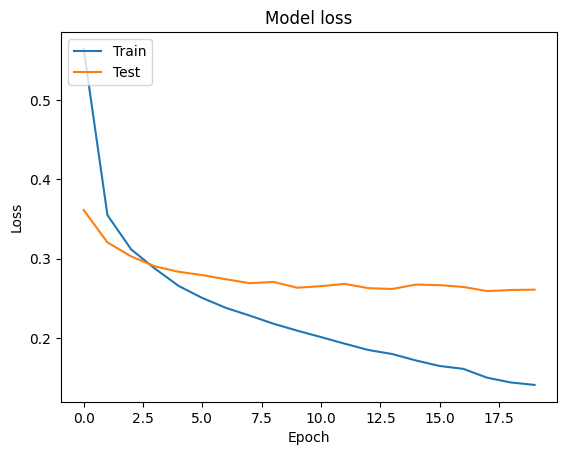

In [9]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.savefig("model_loss.jpg")

In [10]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('fashion_mobilenet.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp0b1pt9vr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  133850918707152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850918707536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850918707920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850918708112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850918703888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850918708304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850918707344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850918709072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850918707728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850918706960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13385091870

In [11]:
import os
h5_size = os.path.getsize('MobileNet_Model.h5') / (1024*1024)
tflite_size = os.path.getsize('fashion_mobilenet.tflite') / (1024*1024)
print(f"Keras model: {h5_size:.2f} MB")
print(f"TFLite model: {tflite_size:.2f} MB")

Keras model: 10.86 MB
TFLite model: 9.08 MB


In [12]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()

with open('fashion_mobilenet_quant.tflite', 'wb') as f:
    f.write(tflite_quant_model)

quant_size = os.path.getsize('fashion_mobilenet_quant.tflite') / (1024*1024)
print(f"Quantized TFLite model: {quant_size:.2f} MB")

Saved artifact at '/tmp/tmpyrt_t_5o'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  133850918707152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850918707536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850918707920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850918708112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850918703888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850918708304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850918707344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850918709072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850918707728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133850918706960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13385091870

In [13]:
import numpy as np

# Load the TFLite interpreter
interpreter = tf.lite.Interpreter(model_path='fashion_mobilenet_quant.tflite')
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Grab a small batch of test images from your preprocessed test_ds
test_batch = next(iter(test_ds.take(1)))
images, labels = test_batch
images = images[:5].numpy()   # test on 5 images
true_labels = labels[:5].numpy()

# --- Predictions from the original Keras model ---
keras_preds = model.predict(images, verbose=0)
keras_classes = np.argmax(keras_preds, axis=1)

# --- Predictions from the TFLite quantized model ---
tflite_classes = []
for img in images:
    img_input = np.expand_dims(img, axis=0).astype(input_details[0]['dtype'])
    interpreter.set_tensor(input_details[0]['index'], img_input)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    tflite_classes.append(np.argmax(output))

tflite_classes = np.array(tflite_classes)

# --- Compare ---
print("True labels:      ", true_labels)
print("Keras predictions:", keras_classes)
print("TFLite predictions:", tflite_classes)
print("Match:", np.array_equal(keras_classes, tflite_classes))

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


True labels:       [9 2 1 1 6]
Keras predictions: [9 2 1 1 0]
TFLite predictions: [9 2 1 1 0]
Match: True
